## 005 - AppleCider spectra
<a id='index'></a> <br>

In [1]:
import os
import sys
sys.path.insert(0, 'AppleCider')

## so many plots
import AppleCider.preprocess.plot_data as plot_data
from AppleCider.preprocess.plot_data import plot_images
import AppleCider.preprocess.more_info as more_info
from AppleCider.preprocess.plot_data import plot_dataset

from AppleCider.core.dataset import DataGenerator
import AppleCider.core.drink as drink


from datetime import datetime
import wandb
import joblib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import pickle

In [2]:
CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']
data_dir = '/SEDM_folder'

data_train = pd.read_csv('/csv-pkl/data_train_BTS.csv')

SEDM_dataset = pd.read_csv('/csv-pkl/SEDM_BrightTransientSurvey.csv')

In [3]:
config = {
        'project': 'AppleCider',
        'mode': 'spectra',    # 'clip' 'photo' 'spectra' 'meta' 'image' 'all'
        'config_from': None,    # 'meridk/AstroCLIPResults/d2u52yml',
        'random_seed': 42,  # 42, 66, 0, 12, 123
        'use_wandb': True,
        'save_weights': False,
        'weights_path': f'AppleCider/weights/spectra/{datetime.now().strftime("%Y-%m-%d-%H-%M")}',
        'use_pretrain': None,
        'freeze': False,

        # Data General
        'preprocessed_path':'/data_train_BTS/',
        'df_path': '/csv-pkl/data_train_BTS.csv',
        
        # save train, val file names ...
        'train_files_path': '/csv-pkl/train_files_BTS.pkl',
        'val_files_path': '/csv-pkl/val_files_BTS.pkl',
        'generate_train_val_files': False,
        
        'step': 'type',
        'classes': CLASSES,
        'group_labels': False,
        'max_samples': 5000,
        'num_classes': len(CLASSES),

        # Photometry Model
        'seq_len': 230,
        'p_enc_in': 4,
        'p_d_model': 128,
        'p_dropout': 0.2,
        'p_factor': 1,
        'p_output_attention': False,
        'p_n_heads': 12,
        'p_d_ff': 512,
        'p_activation': 'gelu',
        'p_e_layers': 8,

        # Spectra Model
        's_dropout': 0.2,
        's_conv_channels': [1, 64, 64, 32, 32],
        's_kernel_size': 3,
        's_mp_kernel_size': 4,

        # Metadata Model
        'm_hidden_dim': 512,
        'm_dropout': 0.2,
        # TODO use actual column names
        'meta_cols': range(10),
        'scaler_path': '/csv-pkl/scaler_BTS.pkl',

        # Image Model
        'input_channels': 3,
        'conv1_channels': 64,
        'conv2_channels': 16,
        'conv_kernel': 3,
        'conv_dropout1': 0.45,
        'conv_dropout2': 0.65,

        # MultiModal Model
        'hidden_dim': 512,
        'fusion': 'avg',  # 'avg', 'concat'

        # Training
        'batch_size': 512,
        'lr': 0.001,
        'beta1': 0.9,
        'beta2': 0.999,
        'weight_decay': 0.01,
        'epochs':30,
        'early_stopping_patience': 29,
        'scheduler': 'ReduceLROnPlateau',  # 'ExponentialLR', 'ReduceLROnPlateau'
        'gamma': 0.9,  # for ExponentialLR scheduler
        'factor': 0.3,  # for ReduceLROnPlateau scheduler
        'patience': 3,  # for ReduceLROnPlateau scheduler
        'warmup': False,
        'warmup_epochs': 100,
        'clip_grad': False,
        'clip_value': 5
    }

In [ ]:
wandb.init(
    project=config['project'],
    config=config, group='spectra',
    job_type='train')

In [5]:
train_dataset = DataGenerator(config=config, split='train')
val_dataset = DataGenerator(config=config, split='val')

ZTF18aahhqih: ZTF18aahhqih_alert_4.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([3.0533e-01, 8.1280e-02, 6.8651e+00, 8.2500e+00, 2.3301e+02, 6.8242e+01,
        1.8000e+01, 3.6600e-01, 9.9000e+01, 6.2085e-02], dtype=torch.float64)


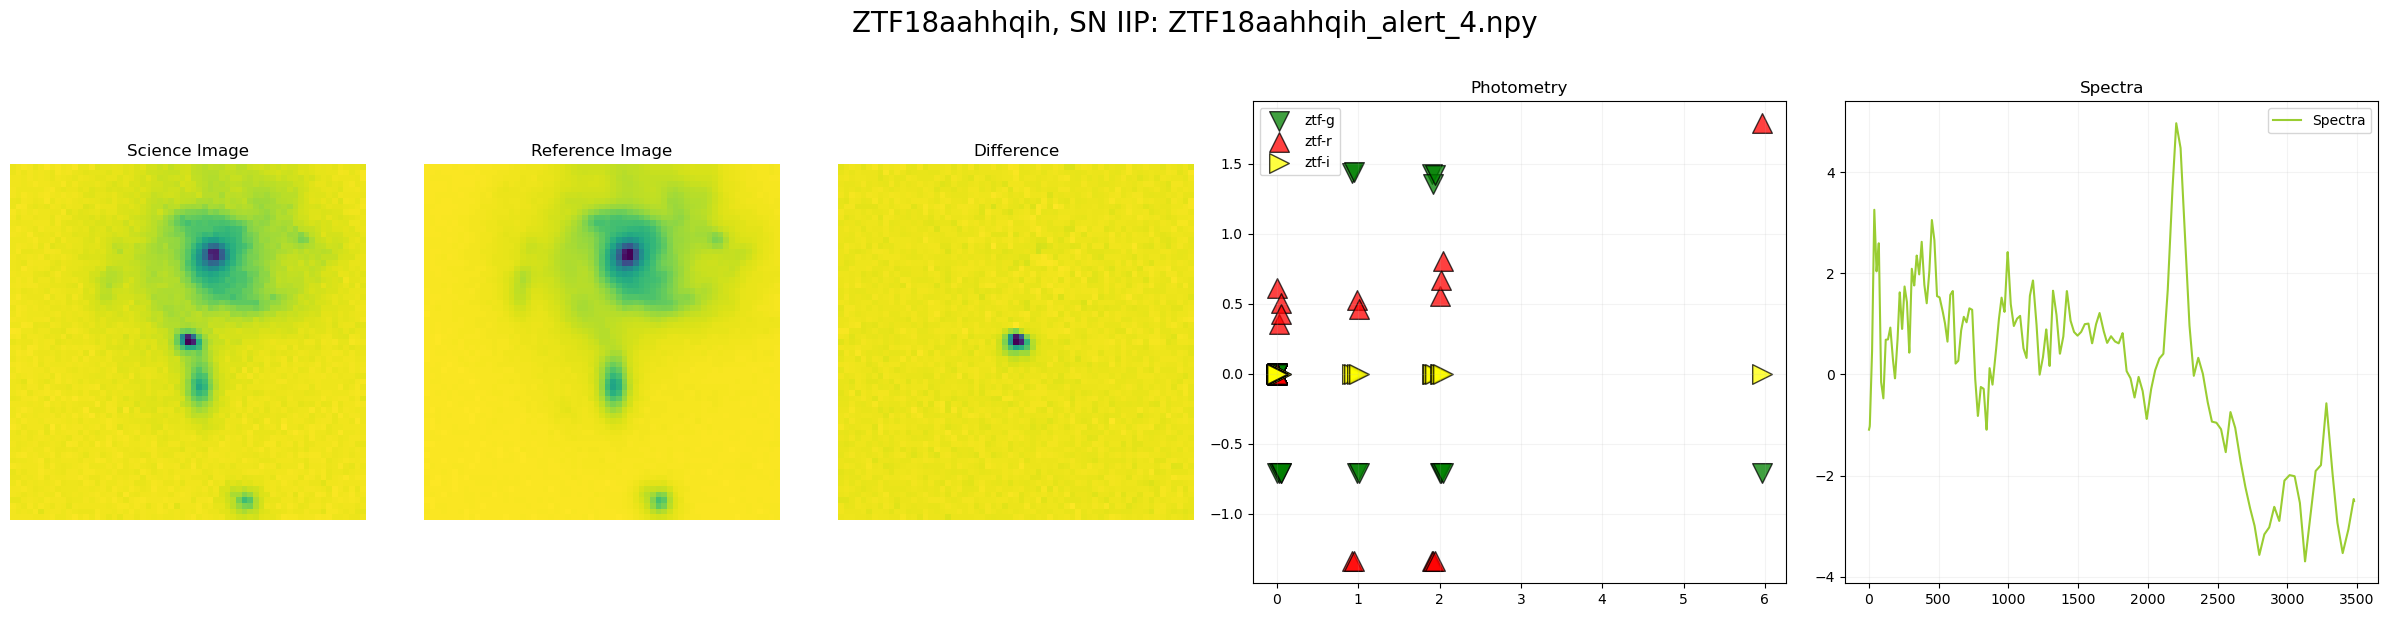

In [6]:
plot_dataset.plot_dataset_item(train_dataset, 50, data_train)

In [ ]:
drink.run(config)

Using cpu


Train:   0%|          | 0/12 [00:00<?, ?it/s]

Validation:   0%|          | 0/4 [00:00<?, ?it/s]